
# Compact Transformer Sentiment Classifier (IMDB)

This notebook implements the full pipeline you described:

- CSV ingest with `"positive"/"negative"` → binary labels (`1/0`) and optional subsampling via `SUBSET` or `N_SAMPLES`
- Regex tokenizer (lowercase) and training-only vocabulary with `PAD/UNK`, frequency filtering, and optional `top_k`
- Encode reviews to integer IDs
- PyTorch `DataLoader`s with **dynamic per-batch padding** capped by `MAX_LEN`
- Model: token embeddings + **sinusoidal positional encoding** + **`nn.TransformerEncoder`**
- Mean-pool **non-PAD** positions → dropout → linear classifier
- Training with **AdamW**, **CrossEntropyLoss**, **gradient clipping**
- Best model state + vocabulary saved
- Per-epoch **train/val/test loss & accuracy**
- **Attention visualization hooks** to extract and plot self-attention patterns
- Optional **LR scheduler** and **early stopping**

> Set `DATA_CSV` to your IMDB CSV file. It should contain text and label columns (see the "Data Ingest" cell for details).


In [1]:
import pandas as pd
from datasets import load_dataset

# Load IMDB dataset from HuggingFace
imdb = load_dataset("imdb")

# Convert to Python lists and merge train + test splits
train_texts = list(imdb["train"]["text"])
test_texts = list(imdb["test"]["text"])
train_labels = list(imdb["train"]["label"])
test_labels = list(imdb["test"]["label"])

# Combine splits
texts = train_texts + test_texts
labels = train_labels + test_labels

# Build DataFrame
df = pd.DataFrame({
    "review": texts,
    "sentiment": ["positive" if l == 1 else "negative" for l in labels],
})

# Save to CSV
df.to_csv("imdb_reviews.csv", index=False)
print(f"✅ Saved imdb_reviews.csv with {len(df)} rows")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

✅ Saved imdb_reviews.csv with 50000 rows


In [2]:

# === Configuration ===
from dataclasses import dataclass

@dataclass
class Config:
    DATA_CSV: str = "imdb_reviews.csv"  # <-- Set your CSV path here
    TEXT_COL: str = "review"            # name of text column in CSV
    LABEL_COL: str = "sentiment"        # name of label column in CSV ("positive"/"negative" or 1/0)

    OUTPUT_DIR: str = "./outputs"
    RANDOM_SEED: int = 42

    # Subsampling for fast experiments (set only one of these)
    SUBSET: float | None = 0.10  # e.g., 0.10 for 10% (None to disable)
    N_SAMPLES: int | None = None # e.g., 5000  (None to disable)

    # Vocab
    MIN_FREQ: int = 2
    TOP_K: int | None = 50000   # cap vocabulary size (excluding special tokens). None = no cap
    PAD_TOKEN: str = "<pad>"
    UNK_TOKEN: str = "<unk>"

    # Sequence / batching
    MAX_LEN: int = 256          # hard cap on sequence length
    BATCH_SIZE: int = 64
    NUM_WORKERS: int = 0        # set >0 if you want multi-process dataloading

    # Model
    EMBED_DIM: int = 128
    N_HEAD: int = 2
    FF_DIM: int = 256
    NUM_LAYERS: int = 2
    DROPOUT: float = 0.1

    # Train
    EPOCHS: int = 5
    LR: float = 2e-4
    WEIGHT_DECAY: float = 0.01
    MAX_NORM: float = 1.0        # gradient clipping
    USE_SCHEDULER: bool = True
    EARLY_STOPPING_PATIENCE: int = 3

cfg = Config()
print(cfg)


Config(DATA_CSV='imdb_reviews.csv', TEXT_COL='review', LABEL_COL='sentiment', OUTPUT_DIR='./outputs', RANDOM_SEED=42, SUBSET=0.1, N_SAMPLES=None, MIN_FREQ=2, TOP_K=50000, PAD_TOKEN='<pad>', UNK_TOKEN='<unk>', MAX_LEN=256, BATCH_SIZE=64, NUM_WORKERS=0, EMBED_DIM=128, N_HEAD=2, FF_DIM=256, NUM_LAYERS=2, DROPOUT=0.1, EPOCHS=5, LR=0.0002, WEIGHT_DECAY=0.01, MAX_NORM=1.0, USE_SCHEDULER=True, EARLY_STOPPING_PATIENCE=3)


In [3]:

# === Imports & Reproducibility ===
import os, json, re, math, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.nn.utils.rnn import pad_sequence
from torch.nn.utils import clip_grad_norm_
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(cfg.RANDOM_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')


## Data Ingest

Expected CSV columns:
- `TEXT_COL` (default `"review"`): raw review text
- `LABEL_COL` (default `"sentiment"`): either `"positive"/"negative"` or `1/0`

We map `"positive"→1` and `"negative"→0` if the column is string-valued.
We also support quick experimentation via `SUBSET` or `N_SAMPLES` (applied before the train/val/test split).


In [4]:

# === Load CSV and map labels ===
df = pd.read_csv(cfg.DATA_CSV)

# Normalize label to 0/1
if df[cfg.LABEL_COL].dtype == 'O':
    df[cfg.LABEL_COL] = df[cfg.LABEL_COL].str.strip().str.lower().map({"positive": 1, "negative": 0})
else:
    df[cfg.LABEL_COL] = df[cfg.LABEL_COL].astype(int).clip(0,1)

# Optional subsample for speed
if cfg.N_SAMPLES is not None:
    df = df.sample(n=min(cfg.N_SAMPLES, len(df)), random_state=cfg.RANDOM_SEED)
elif cfg.SUBSET is not None:
    frac = float(cfg.SUBSET)
    df = df.sample(frac=max(0.0, min(1.0, frac)), random_state=cfg.RANDOM_SEED)

df = df.dropna(subset=[cfg.TEXT_COL, cfg.LABEL_COL]).reset_index(drop=True)
len(df), df.head()


(5000,
                                               review  sentiment
 0  Forget what I said about Emeril. Rachael Ray i...          0
 1  Former private eye-turned-security guard ditch...          0
 2  Mann photographs the Alberta Rocky Mountains i...          0
 3  Simply put: the movie is boring. Cliché upon c...          0
 4  Now being a fan of sci fi, the trailer for thi...          1)


## Tokenization (Regex Lowercase)

A simple, explainable tokenizer that lowercases and splits on word characters.


In [5]:

token_pattern = re.compile(r"[A-Za-z0-9']+")

def regex_tokenize(text: str) -> list[str]:
    text = str(text).lower()
    return token_pattern.findall(text)

# Quick smoke test
print(regex_tokenize("This, right here, is a test! It's #1, okay?"))


['this', 'right', 'here', 'is', 'a', 'test', "it's", '1', 'okay']



## Vocabulary (Train-Only)

We build a vocabulary from **training data only**, add `PAD/UNK` tokens, apply a minimum frequency filter, and optionally cap at `TOP_K`.


In [6]:

# Train/Val/Test split BEFORE vocab build (train-only vocab)
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df[cfg.TEXT_COL].tolist(),
    df[cfg.LABEL_COL].tolist(),
    test_size=0.2,
    random_state=cfg.RANDOM_SEED,
    stratify=df[cfg.LABEL_COL].tolist()
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=cfg.RANDOM_SEED, stratify=temp_labels
)

from collections import Counter
counter = Counter()
for t in train_texts:
    counter.update(regex_tokenize(t))

# Apply min freq
items = [(w, c) for w, c in counter.items() if c >= cfg.MIN_FREQ]
# Sort by frequency
items.sort(key=lambda x: (-x[1], x[0]))

# Apply TOP_K (excluding special tokens)
if cfg.TOP_K is not None:
    items = items[:cfg.TOP_K]

itos = [cfg.PAD_TOKEN, cfg.UNK_TOKEN] + [w for w, _ in items]
stoi = {w: i for i, w in enumerate(itos)}
PAD_ID = stoi[cfg.PAD_TOKEN]
UNK_ID = stoi[cfg.UNK_TOKEN]

len(itos), itos[:10]


(21781, ['<pad>', '<unk>', 'the', 'and', 'a', 'of', 'to', 'is', 'br', 'in'])


## Encoding to IDs

We convert tokens to integer IDs using the vocabulary. Unknown tokens map to `UNK`.


In [7]:

def encode(text: str) -> list[int]:
    toks = regex_tokenize(text)
    return [stoi.get(tok, UNK_ID) for tok in toks]

X_train = [encode(t) for t in train_texts]
X_val = [encode(t) for t in val_texts]
X_test = [encode(t) for t in test_texts]

y_train = torch.tensor(train_labels, dtype=torch.long)
y_val = torch.tensor(val_labels, dtype=torch.long)
y_test = torch.tensor(test_labels, dtype=torch.long)

len(X_train), len(X_val), len(X_test), y_train.shape, y_val.shape, y_test.shape


(4000, 500, 500, torch.Size([4000]), torch.Size([500]), torch.Size([500]))


## Dataset & Dynamic Padding

We implement a custom `collate_fn` that:
- truncates sequences to `MAX_LEN`
- dynamically pads per-batch to the longest example in that batch
- returns `src_key_padding_mask` for the Transformer


In [8]:

class ListDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def collate_fn(batch):
    xs, ys = zip(*batch)
    # Truncate before padding
    xs = [torch.tensor(x[:cfg.MAX_LEN], dtype=torch.long) for x in xs]
    lengths = torch.tensor([len(x) for x in xs], dtype=torch.long)
    padded = pad_sequence(xs, batch_first=True, padding_value=PAD_ID)
    # src_key_padding_mask: True where PAD
    pad_mask = (padded == PAD_ID)
    return padded, torch.tensor(ys, dtype=torch.long), pad_mask, lengths

train_ds = ListDataset(X_train, y_train)
val_ds   = ListDataset(X_val, y_val)
test_ds  = ListDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                          num_workers=cfg.NUM_WORKERS, collate_fn=collate_fn, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=cfg.NUM_WORKERS, collate_fn=collate_fn, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=cfg.NUM_WORKERS, collate_fn=collate_fn, drop_last=False)

next(iter(train_loader))[0].shape


torch.Size([64, 256])


## Model

- Token embeddings
- **Sinusoidal positional encoding**
- `nn.TransformerEncoder` (configurable layers/heads/ff size/dropout)
- Mean-pool over **non-PAD** tokens
- Classifier head
- Hooks to **capture attention weights** for visualization


In [9]:
# ==== REPLACE YOUR MODEL CELL WITH THIS ====
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 10000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        T = x.size(1)
        return x + self.pe[:T].unsqueeze(0)

class EncoderLayerWithWeights(nn.Module):
    """A Transformer encoder layer that ALWAYS returns attention weights."""
    def __init__(self, d_model: int, nhead: int, dim_feedforward: int, dropout: float, batch_first: bool = True):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=nhead, dropout=dropout, batch_first=batch_first
        )
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.activation = F.relu  # you can swap to gelu if you prefer

    def forward(self, src, src_key_padding_mask=None):
        # Self-attention (force need_weights=True to get attn maps)
        attn_output, attn_weights = self.self_attn(
            src, src, src,
            key_padding_mask=src_key_padding_mask,
            need_weights=True,
            average_attn_weights=False  # keep per-head maps
        )
        src = src + self.dropout1(attn_output)
        src = self.norm1(src)

        # FFN
        ffn = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(ffn)
        src = self.norm2(src)

        return src, attn_weights  # [B, heads, T, T]

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size: int, d_model: int, nhead: int, ff_dim: int, num_layers: int, dropout: float, pad_id: int):
        super().__init__()
        self.pad_id = pad_id
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.posenc = SinusoidalPositionalEncoding(d_model)
        self.layers = nn.ModuleList([
            EncoderLayerWithWeights(d_model=d_model, nhead=nhead, dim_feedforward=ff_dim, dropout=dropout, batch_first=True)
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, 2)

        # container for captured attention maps: list of [B, heads, T, T] per layer
        self.attn_maps = []

    def forward(self, x, pad_mask):
        # x: [B, T], pad_mask: [B, T] (True for PAD)
        x = self.embed(x)              # [B, T, D]
        x = self.posenc(x)             # add sinusoidal PE

        self.attn_maps = []
        enc = x
        for layer in self.layers:
            enc, attn_w = layer(enc, src_key_padding_mask=pad_mask)
            # Some torch versions might (rarely) return None; guard it
            if attn_w is not None:
                self.attn_maps.append(attn_w.detach().cpu())

        # Masked mean-pooling over non-PAD tokens
        lengths = (~pad_mask).sum(dim=1).clamp(min=1).unsqueeze(-1)      # [B,1]
        masked_enc = enc.masked_fill(pad_mask.unsqueeze(-1), 0.0)        # [B,T,D]
        pooled = masked_enc.sum(dim=1) / lengths                         # [B,D]

        logits = self.classifier(self.dropout(pooled))                   # [B,2]
        return logits

    def close_attn_hooks(self):
        # no external hooks needed anymore
        pass



## Training & Evaluation Utilities


In [10]:

class EarlyStopping:
    def __init__(self, patience=3, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best = None
        self.count = 0
        self.should_stop = False

    def step(self, metric):
        if self.best is None:
            self.best = metric
            return
        improved = (metric > self.best) if self.mode == "max" else (metric < self.best)
        if improved:
            self.best = metric
            self.count = 0
        else:
            self.count += 1
            if self.count >= self.patience:
                self.should_stop = True

def run_epoch(model, loader, optimizer=None, scheduler=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, total_correct, total_count = 0.0, 0, 0
    all_logits = []
    for x, y, pad_mask, _lengths in loader:
        x = x.to(device)
        y = y.to(device)
        pad_mask = pad_mask.to(device)

        logits = model(x, pad_mask)
        loss = F.cross_entropy(logits, y)
        if is_train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            clip_grad_norm_(model.parameters(), cfg.MAX_NORM)
            optimizer.step()
            if scheduler is not None and hasattr(scheduler, "step") and not isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_count += x.size(0)
        all_logits.append(logits.detach().cpu())

    avg_loss = total_loss / max(1, total_count)
    acc = total_correct / max(1, total_count)
    return avg_loss, acc

def evaluate(model, loader):
    model.eval()
    with torch.no_grad():
        return run_epoch(model, loader, optimizer=None)

def train_model(model, train_loader, val_loader):
    optimizer = AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)

    # ReduceLROnPlateau without 'verbose' for broad compatibility
    plateau = None
    if cfg.USE_SCHEDULER:
        plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=1
        )

    early = EarlyStopping(patience=cfg.EARLY_STOPPING_PATIENCE, mode="max")

    best_val_acc = -1.0
    best_state = None
    history = []

    for epoch in range(1, cfg.EPOCHS + 1):
        train_loss, train_acc = run_epoch(model, train_loader, optimizer=optimizer)
        val_loss, val_acc = evaluate(model, val_loader)

        if plateau is not None:
            plateau.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "lr": optimizer.param_groups[0]["lr"],
        })
        print(
            f"Epoch {epoch:02d} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
            f"lr {optimizer.param_groups[0]['lr']:.2e}"
        )

        early.step(val_acc)
        if early.should_stop:
            print("Early stopping triggered.")
            break

    # Save best weights + vocab
    save_dir = cfg.OUTPUT_DIR
    os.makedirs(save_dir, exist_ok=True)
    best_path = os.path.join(save_dir, "best_model.pt")
    torch.save(best_state, best_path)

    vocab_path = os.path.join(save_dir, "vocab.json")
    with open(vocab_path, "w", encoding="utf-8") as f:
        json.dump({"itos": itos, "stoi": stoi, "pad_id": PAD_ID, "unk_id": UNK_ID}, f, ensure_ascii=False)

    return history, best_path, vocab_path


    # Save best
    save_dir = cfg.OUTPUT_DIR
    os.makedirs(save_dir, exist_ok=True)
    best_path = os.path.join(save_dir, "best_model.pt")
    torch.save(best_state, best_path)

    vocab_path = os.path.join(save_dir, "vocab.json")
    with open(vocab_path, "w", encoding="utf-8") as f:
        json.dump({"itos": itos, "stoi": stoi, "pad_id": PAD_ID, "unk_id": UNK_ID}, f, ensure_ascii=False)

    return history, best_path, vocab_path


In [11]:

# === Initialize model ===
vocab_size = len(itos)
model = TransformerClassifier(
    vocab_size=vocab_size,
    d_model=cfg.EMBED_DIM,
    nhead=cfg.N_HEAD,
    ff_dim=cfg.FF_DIM,
    num_layers=cfg.NUM_LAYERS,
    dropout=cfg.DROPOUT,
    pad_id=PAD_ID,
).to(device)

sum(p.numel() for p in model.parameters())/1e6, "million params"


(3.053186, 'million params')


## Train


In [12]:
history, best_path, vocab_path = train_model(model, train_loader, val_loader)
print("Saved:", best_path, "and", vocab_path)


Epoch 01 | train loss 0.6928 acc 0.5278 | val loss 0.6730 acc 0.6180 | lr 2.00e-04
Epoch 02 | train loss 0.6567 acc 0.6038 | val loss 0.6050 acc 0.6620 | lr 2.00e-04
Epoch 03 | train loss 0.5863 acc 0.6847 | val loss 0.5659 acc 0.6940 | lr 2.00e-04
Epoch 04 | train loss 0.5539 acc 0.7180 | val loss 0.5500 acc 0.7220 | lr 2.00e-04
Epoch 05 | train loss 0.5134 acc 0.7428 | val loss 0.5808 acc 0.7120 | lr 2.00e-04
Saved: ./outputs/best_model.pt and ./outputs/vocab.json



## Test Evaluation


In [13]:

# Load best weights for testing
state = torch.load(best_path, map_location="cpu")
model.load_state_dict(state)

test_loss, test_acc = evaluate(model, test_loader)
print(f"TEST | loss {test_loss:.4f} acc {test_acc:.4f}")


TEST | loss 0.6013 acc 0.6680



## Attention Visualization

Run a forward pass on a small batch, capture attention maps from each encoder layer, and plot a head from a chosen layer.


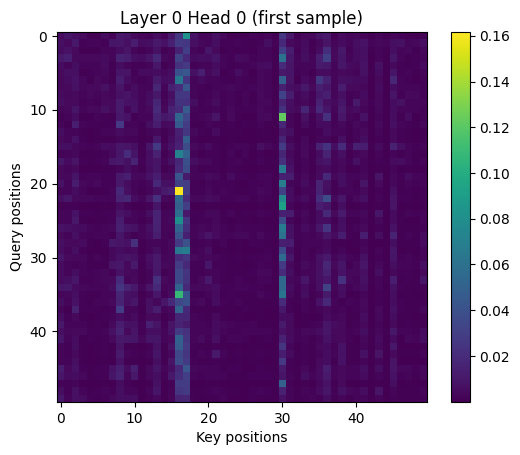

In [18]:

def visualize_attention_on_batch(model, loader, batch_index=0, layer_index=0, head_index=0, max_tokens_to_show=50):
    model.eval()
    with torch.no_grad():
        for b_idx, (x, y, pad_mask, _lengths) in enumerate(loader):
            if b_idx == batch_index:
                x = x.to(device); pad_mask = pad_mask.to(device)
                _ = model(x, pad_mask)  # forward to collect attn
                if not model.attn_maps:
                    print("No attention maps captured.")
                    return
                # model.attn_maps is a list per layer forward calls (length = NUM_LAYERS)
                layer_attn = model.attn_maps[layer_index]  # [B, heads, T, T]
                # Pick the first sequence in batch
                attn = layer_attn[0].cpu().numpy()  # [heads, T, T]
                head = attn[head_index]
                T = min(head.shape[-1], max_tokens_to_show)
                plt.figure()
                plt.imshow(head[:T, :T])
                plt.title(f"Layer {layer_index} Head {head_index} (first sample)")
                plt.xlabel("Key positions")
                plt.ylabel("Query positions")
                plt.colorbar()
                plt.show()
                return
    print("Batch index out of range.")

# Example (adjust indices as needed)
visualize_attention_on_batch(model, val_loader, batch_index=0, layer_index=0, head_index=0, max_tokens_to_show=50)
